# Explore events
Hillas parameter distributions, image centroids and reconstructed events for a chosen set of telescopes and cuts,
from already processed data (run `process_pff.ipynb` first).

Everything is set in **Selection** below: pick a config, then override any of its telescopes, nights or cuts there to
compare selections without editing the config.

# Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from heap import diagnostics as dg
from heap import events as ev
from heap import significance as sg
from heap.config import load_analysis_config
from heap.parameterize import CAMERA_HALF_WIDTH, TAB10_COLORS
from heap.process_dataset import slugify
from heap.reconstruction import reconstruct_directions
from heap.sources import SOURCES

# Selection

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
SOURCE_POSITION = SOURCES.get(SOURCE)

# override any of these, e.g. TELESCOPES = ["Fern", "Winter"] or IMAGE_CUTS = {"width": ("value", 0.3)}
DATES = cfg["source"]["dates"] # None = every night in OUTPUT_DIR with SOURCE
TELESCOPES = cfg["cuts"]["telescopes"] # only these telescopes' images are matched into events
REFERENCE = cfg["events"]["reference"]
MIN_TEL = cfg["cuts"]["min_tel"]
MIN_NPIX = cfg["cuts"]["min_npix"]
IMAGE_CUTS = cfg["cuts"]["image_cuts"] # {column: (mode, threshold)}, see heap.events.apply_cut()

# event building
COINC_WINDOW = cfg["events"]["coinc_window"]
ROTATE_POSTFLIP = cfg["events"]["rotate_postflip"]
REL_TEL_EFFICIENCY = cfg["events"]["rel_tel_efficiency"]
POINTING_CORRECTIONS = cfg["events"]["pointing_corrections"]
WOBBLE_OFFSET = cfg["source"]["wobble_offset"] # deg, see heap.events.wobble_pointings()
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"]

# plotting
N_EVENTS = 4 # reconstructed events to display
PLOT_RADIUS = 3 # deg from the camera center for the direction histogram
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

In [3]:
if DATES is None:
    products = dg.product_table(OUTPUT_DIR)
    DATES = sorted(products[products.Source == slugify(SOURCE, sep="_")].Date.unique())
print(f"{SOURCE}, nights {DATES}, telescopes {TELESCOPES} (reference {REFERENCE})")
print(f"cuts: min_tel {MIN_TEL}, min_npix {MIN_NPIX}, image cuts {IMAGE_CUTS}")

Crab, nights ['20260917', '20260918', '20260922'], telescopes ['Heli', 'Fern', 'Winter', 'Gattini'] (reference ['Winter', 'Fern', 'Heli', 'Gattini'])
cuts: min_tel 2, min_npix 3, image cuts {'width': ('nsigma', 0.5)}


# Events
Images of `TELESCOPES` matched into array events within `COINC_WINDOW` after correcting timestamps against `REFERENCE`
(`heap.events.build_array_events()`), then the cuts (`heap.events.apply_cuts()`).

In [4]:
dfs = []
pointings = {} # each run's pointing, for the source position in plot_event()
for date in DATES:
    night, night_pointings = ev.build_array_events(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW, wobble_offset=WOBBLE_OFFSET,
        rotate_postflip=ROTATE_POSTFLIP, rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS,
        pointing_overrides=POINTING_OVERRIDES,
    )
    pointings |= night_pointings
    if night is None or len(night) == 0:
        print(f"{date}: no {SOURCE} events")
        continue
    night["Event"] += dfs[-1].Event.max() + 1 if dfs else 0 # unique across nights
    dfs.append(night)
df = pd.concat(dfs, ignore_index=True)
array = ev.apply_cuts(df, min_tel=MIN_TEL, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
print(f"{df.Event.nunique()} events ({len(df)} images) before cuts, {array.Event.nunique()} events ({len(array)} images) after")

obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd, 09:51:23-10:51:23 UTC: timing reference Winter; Heli 3357, Fern 3076, Winter 3972, Gattini 3189 images
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  6e-05 s, std= 5e-05 s
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  7e-05 s, std= 5e-05 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  0.00036 s, std= 0.00035 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Heli-Fern within 0.001s: 1612/3353 Heli events (48.1%) and 1612/3076 Fern events (52.4%) coincident, 1614 pairs
Heli-Winter within 0.001s: 1481/3353 Heli events (44.2%) and 1483/3972 Winter events (37.3%) coincident, 1484 pairs
Heli-Gattini within 0.001s: 216/3353 Heli events

In [5]:
# events per telescope combination before cuts, and how many of them still have MIN_TEL+ images after cuts
combo = df.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t)))
n_images = array.Event.value_counts()
kept = combo.index.isin(n_images[n_images >= MIN_TEL].index)
pd.DataFrame({"before cuts": combo.value_counts(), "after cuts": combo[kept].value_counts()}).fillna(0).astype(int)

,before cuts,after cuts
Telescope,,
Fern + Gattini,52,16
Fern + Gattini + Heli,38,34
Fern + Gattini + Heli + Winter,292,239
Fern + Gattini + Winter,11,8
Fern + Heli,6139,3717
Fern + Heli + Winter,6072,4253
Fern + Winter,2346,1594
Gattini + Heli,214,119
Gattini + Heli + Winter,182,164


# Hillas parameters
One line per telescope, all telescopes pooled filled in grey.

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


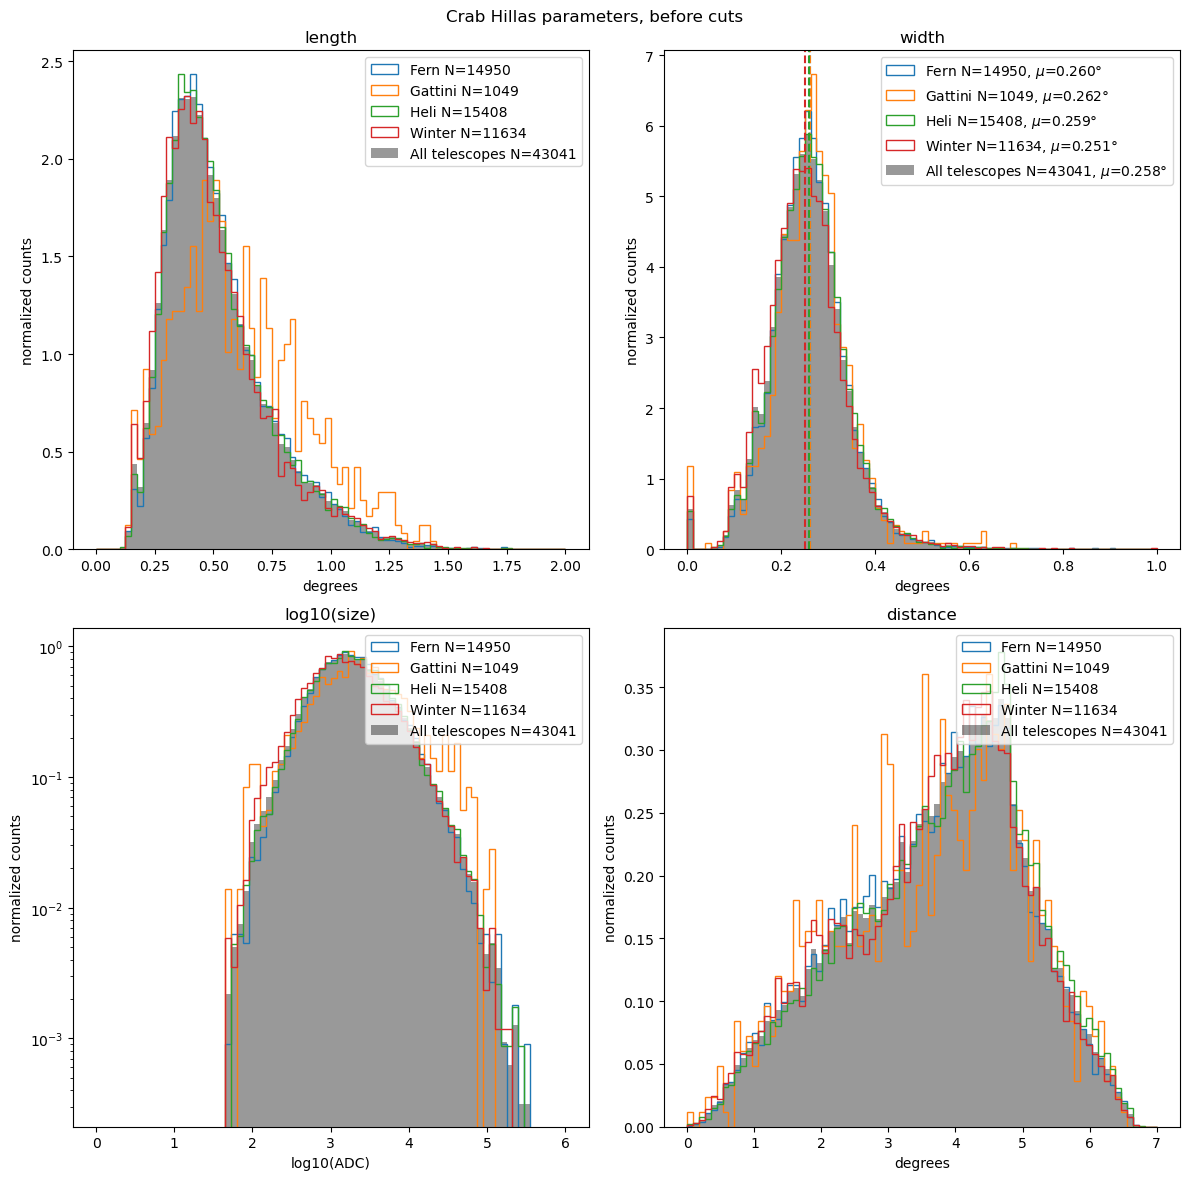

In [6]:
ev.plot_hillas(df, f"{SOURCE} Hillas parameters, before cuts", colors=COLORS)
plt.show()

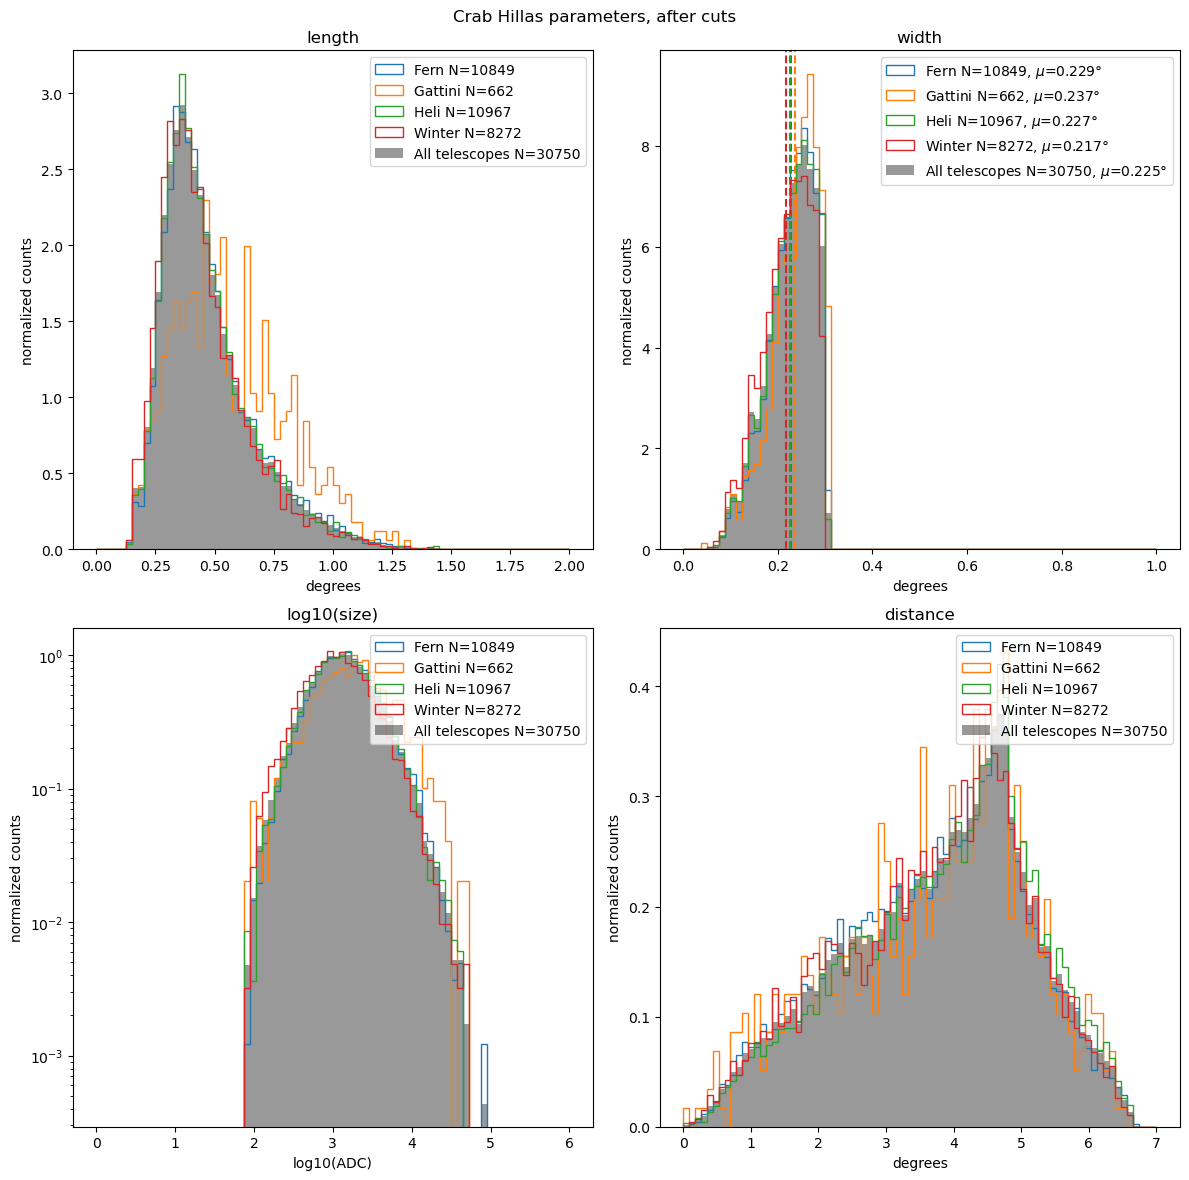

In [7]:
ev.plot_hillas(array, f"{SOURCE} Hillas parameters, after cuts", colors=COLORS)
plt.show()

In [8]:
array.groupby("Telescope")[["N_pix", "size", "length", "width", "distance", "alpha"]].describe().T

Telescope               Fern       Gattini          Heli        Winter
N_pix    count  10849.000000    662.000000  10967.000000   8272.000000
         mean      19.470827     24.537764     18.838971     17.173235
         std       11.334056     14.301834     10.957022     10.573557
         min        3.000000      3.000000      3.000000      3.000000
         25%       11.000000     14.000000     11.000000     10.000000
         50%       17.000000     22.000000     17.000000     15.000000
         75%       25.000000     32.000000     24.000000     22.000000
         max       93.000000     89.000000     93.000000     91.000000
size     count  10849.000000    662.000000  10967.000000   8272.000000
         mean    2214.346446   3288.237019   2152.186472   1849.657052
         std     2907.591435   4681.307516   2825.354396   2646.121817
         min       85.736120     88.640596     77.067131     86.499005
         25%      757.986869    871.747889    729.105472    600.169558
         50%     1369.602260   1843.220474   1335.314732   1097.558191
         75%     2535.298090   3674.074082   2479.598707   2076.637855
         max    83353.540405  52231.056622  43350.821824  51589.108269
length   count  10849.000000    662.000000  10967.000000   8272.000000
         mean       0.475848      0.568022      0.468248      0.451513
         std        0.195816      0.235543      0.192837      0.190112
         min        0.133366      0.147103      0.136277      0.127674
         25%        0.338514      0.384538      0.334202      0.317488
         50%        0.429145      0.530270      0.422784      0.409378
         75%        0.568188      0.721917      0.559218      0.542634
         max        1.726195      1.308265      1.597389      2.074557
width    count  10849.000000    662.000000  10967.000000   8272.000000
         mean       0.228645      0.236629      0.226713      0.217313
         std        0.048431      0.050680      0.049801      0.051352
         min        0.059689      0.046006      0.055405      0.053791
         25%        0.197385      0.206229      0.195181      0.182598
         50%        0.235896      0.247267      0.234350      0.224774
         75%        0.266409      0.274945      0.266498      0.258764
         max        0.302703      0.307883      0.301186      0.295951
distance count  10849.000000    662.000000  10967.000000   8272.000000
         mean       3.695212      3.706808      3.847655      3.701172
         std        1.364040      1.420611      1.356883      1.364795
         min        0.109064      0.031887      0.037067      0.089623
         25%        2.694753      2.657650      2.895613      2.724140
         50%        3.882166      3.966609      4.050915      3.891238
         75%        4.713747      4.744914      4.819052      4.709019
         max        6.677195      6.494345      6.635298      6.632286
alpha    count  10849.000000    662.000000  10967.000000   8272.000000
         mean      44.248888     47.773134     44.871260     43.064050
         std       26.063806     25.334027     26.018513     26.032662
         min        0.016973      0.199237      0.011845      0.022542
         25%       21.600113     26.823040     21.887127     20.530832
         50%       44.635869     48.846181     45.734765     42.142290
         75%       66.307759     69.186831     66.972145     65.296427
         max       89.997559     89.793906     89.999514     89.984168

# Image centroids
Centroids (`x_c`, `y_c`) in camera coordinates, one bin per pixel: postflip images rotated to the preflip orientation, where
+x points east and +y south (see `heap.significance.make_wcs()`).

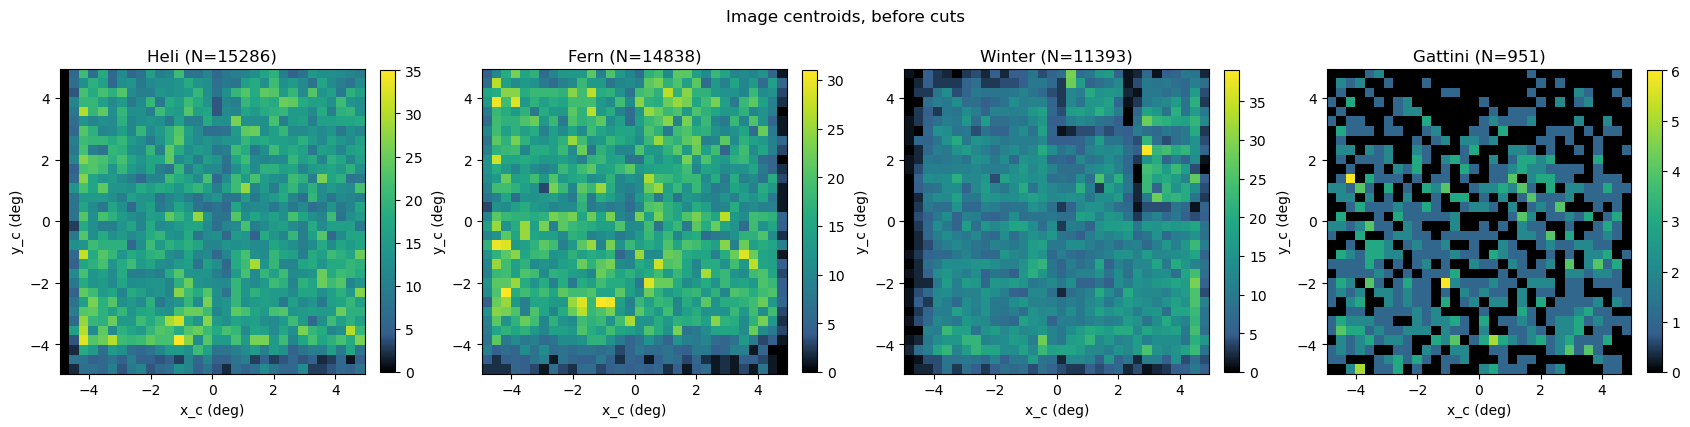

In [9]:
dg.plot_centroids(df, "Image centroids, before cuts", telescopes=TELESCOPES)
plt.show()

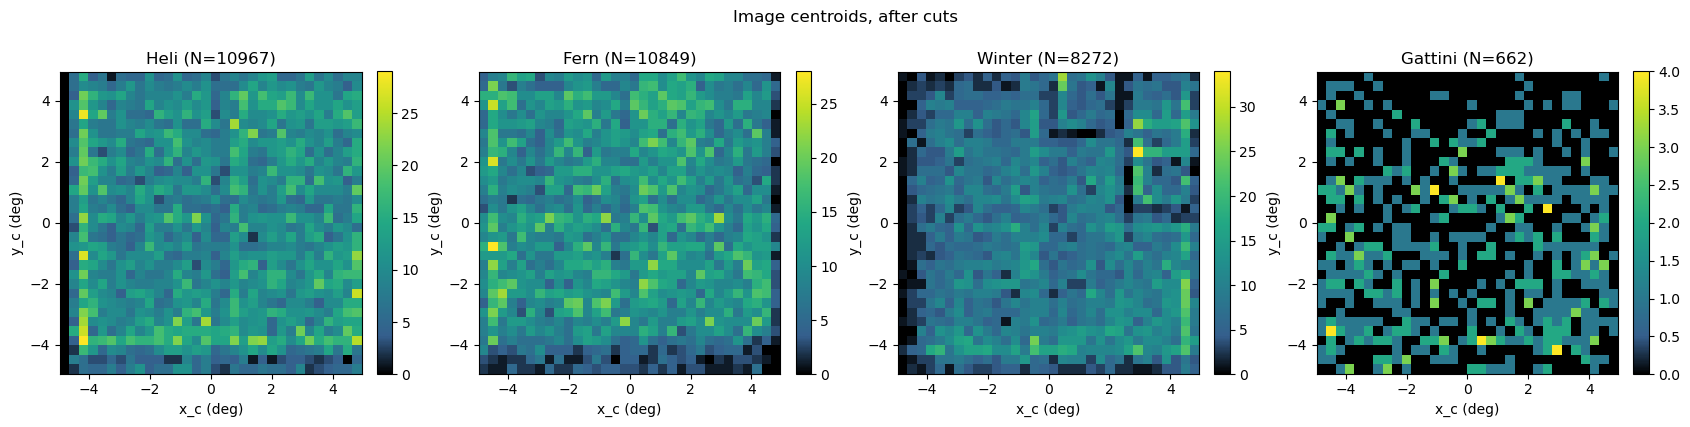

In [10]:
dg.plot_centroids(array, "Image centroids, after cuts", telescopes=TELESCOPES)
plt.show()

## All images
Every image of `TELESCOPES`, coincident or not (`heap.events.load_camera_frames()`), with the image cuts but no
`MIN_TEL`. `"nsigma"` cut thresholds are over all images here, so they differ from the array events' above.

In [11]:
frames = []
for date in DATES:
    night, _ = ev.load_camera_frames(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, wobble_offset=WOBBLE_OFFSET,
        rotate_postflip=ROTATE_POSTFLIP, rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS,
        pointing_overrides=POINTING_OVERRIDES,
    )
    frames += night.values()
images = pd.concat(frames, ignore_index=True)
images["Event"] = images.index # each image its own event, so apply_cuts() needs min_tel=1
images_cut = ev.apply_cuts(images, min_tel=1, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
print(f"{len(images)} images before cuts, {len(images_cut)} after")

138437 images before cuts, 72259 after


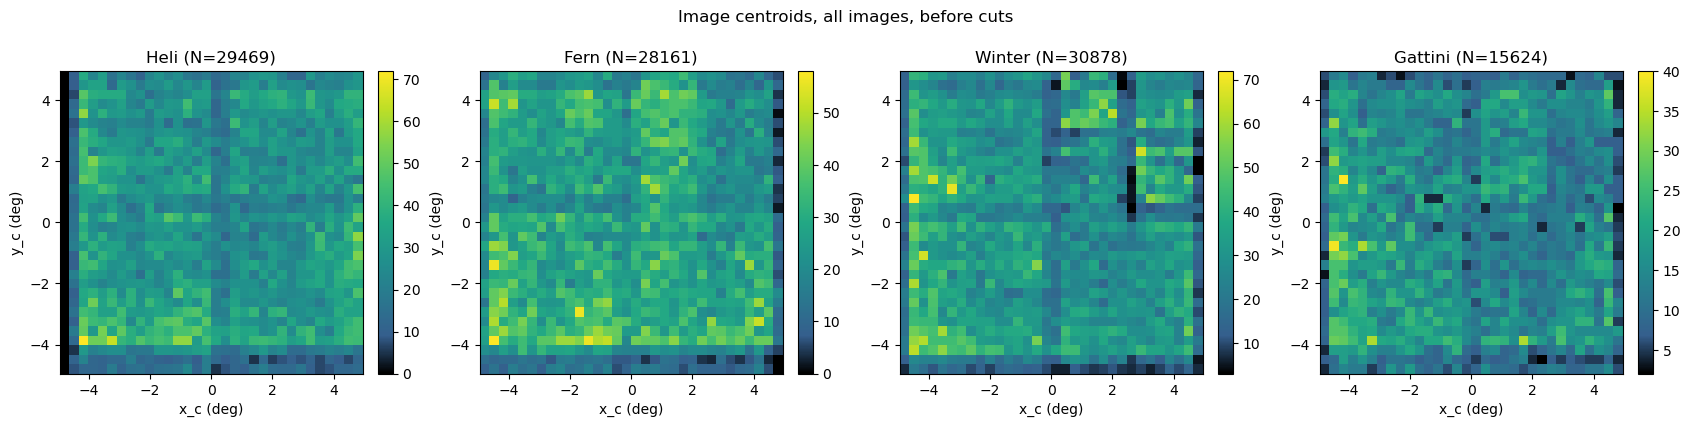

In [12]:
dg.plot_centroids(images, "Image centroids, all images, before cuts", telescopes=TELESCOPES)
plt.show()

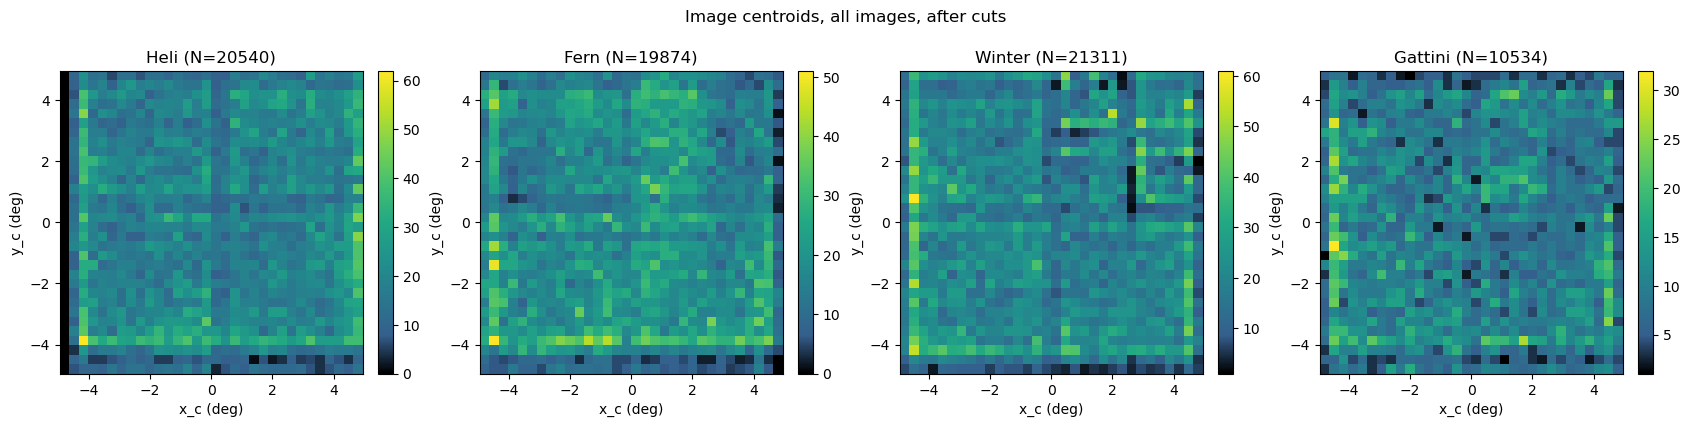

In [13]:
dg.plot_centroids(images_cut, "Image centroids, all images, after cuts", telescopes=TELESCOPES)
plt.show()

## Event display
Each image of an event, then all its Hillas ellipses together. Run the cell again for other events.

In [14]:
# arrival directions (heap.reconstruction)
directions = reconstruct_directions(array)
print(f"{len(directions)} reconstructed events")

11945 reconstructed events


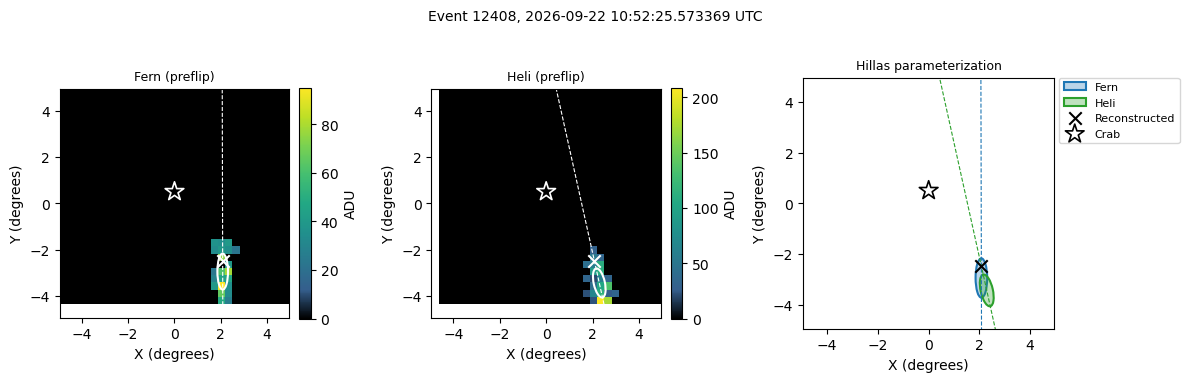

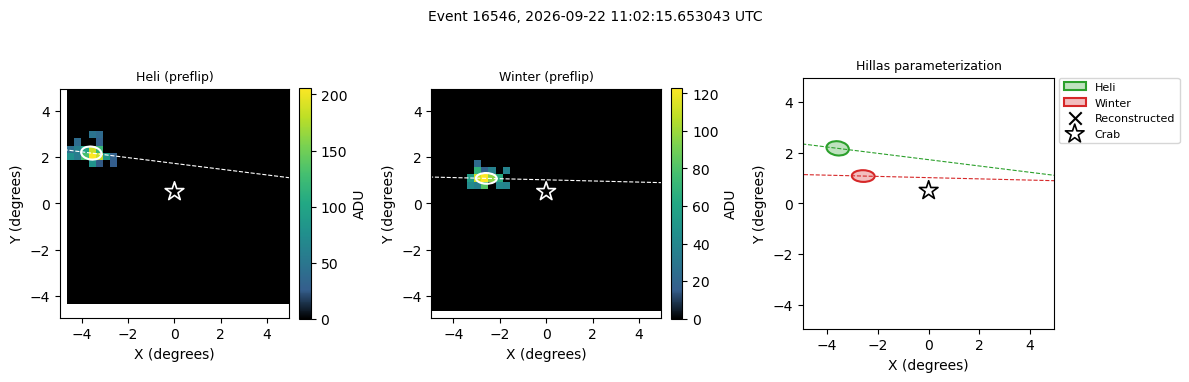

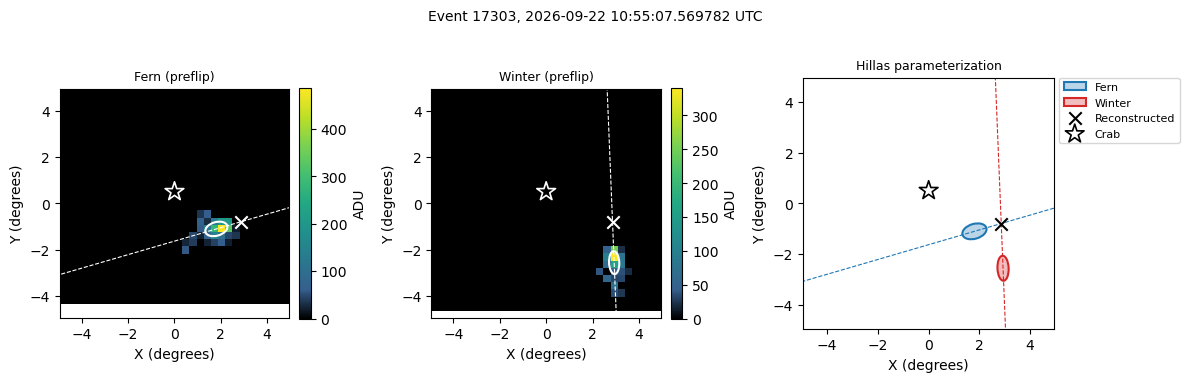

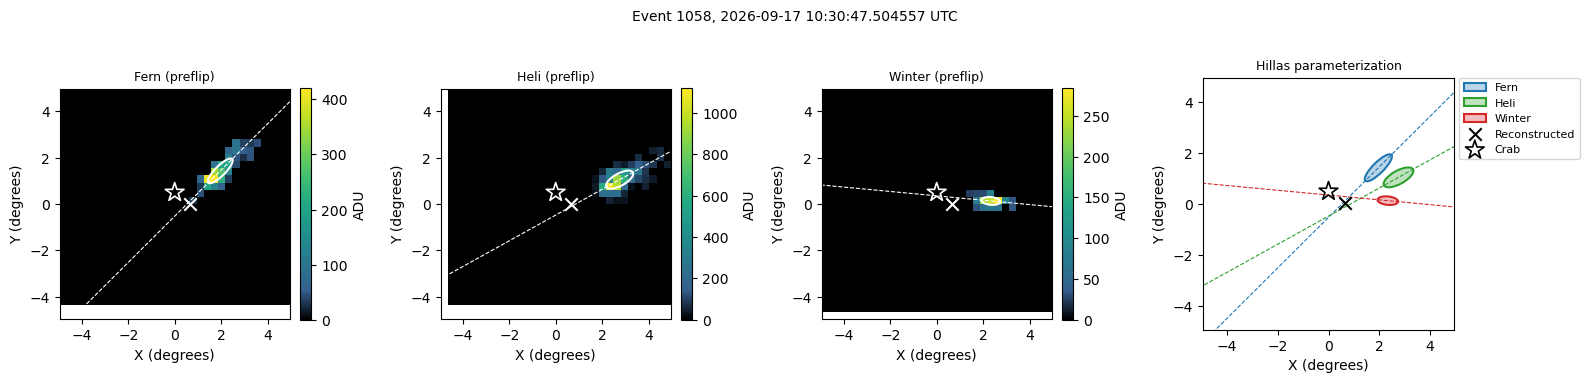

In [15]:
for e in np.random.default_rng().choice(directions.Event, size=min(N_EVENTS, len(directions)), replace=False):
    ev.plot_event(
        array[array.Event == e], directions[directions.Event == e].iloc[0], OUTPUT_DIR, SOURCE,
        source_position=SOURCE_POSITION, pointings=pointings, colors=COLORS,
        rotate_postflip=ROTATE_POSTFLIP,
    )
    plt.show()